# Détection précoce du décrochage étudiant en L1

## Dossier de certification — « Concevoir et implémenter une solution d'intelligence artificielle »

| | |
|---|---|
| **Intitulé du projet** | Détection précoce des étudiants en risque de décrochage en L1 |
| **Type de problème** | Apprentissage supervisé — classification binaire (`abandon`) + régression secondaire (`moyenne_finale`) |
| **Candidat** | *Staudt Michael* |
| **Parcours** | Data Scientist |
| **Date / Version** | *09/07/2026* — v1.1 |
| **Environnement d'exécution** | Python 3.13 · `uv` · scikit-learn, SHAP, XGBoost optionnel · CLI/API FastAPI · exécuté sous Jupyter |
| **Compétences couvertes** | Référentiel complet C1 → C9 |

> **Comment lire ce notebook.** Il est **exécutable de bout en bout** et **lisible sans explication orale**. Chaque grande étape se termine par un **journal de bord** (encadré *JdB*) qui explicite les décisions prises et leur justification. Les fonctions déterministes de nettoyage, d'entraînement, de monitoring et de scoring sont isolées dans le package `src/decrochage/` (reproductibilité, compétence C6) ; le notebook les importe et documente la démarche.


## 1. Résumé exécutif

**Problème métier.** Une université pluridisciplinaire observe un taux d'abandon élevé en L1 (~28 % dans les données). La direction de la réussite étudiante veut **détecter dès le milieu du S1** les étudiants à risque pour déclencher un accompagnement (tutorat, soutien méthodologique, aide sociale).

**Objectif IA.** Estimer, à mi-parcours du S1, la **probabilité de décrochage** de chaque étudiant (`abandon`, classification binaire) et, en cible secondaire, sa **moyenne finale attendue** (`moyenne_finale`, régression) pour calibrer l'intensité de l'accompagnement.

**Approche.** Nettoyage rigoureux de données volontairement « brutes » (doublons, nombres en texte, dates multi-formats, encodages incohérents), **exclusion stricte des fuites** (cible secondaire, identifiants, résultats consolidés de fin de S1) et des **3 leurres**, enrichissement par le catalogue des formations, puis comparaison d'une baseline et de trois familles de modèles, évaluées par la **courbe ROC / AUC**. Le seuil métier est choisi sur validation, puis évalué sur un test hold-out.

**Résultats clés** *(calculés dans ce notebook)*.

| Élément | Valeur |
|---|---|
| Modèle retenu | Régression logistique (régularisée, pondérée) |
| AUC (test) | **0,9486** |
| Seuil métier | **0,30**, choisi sur validation par coût FN:FP = 5:1 |
| Rappel / précision au seuil métier | **95,9 %** / **63,5 %** sur test |
| Facteurs de risque dominants | taux de présence, heures LMS, motivation, taux de rendu, retards |
| Régression `moyenne_finale` | R² ≈ 0,68 · MAE ≈ 2,3 pts |

**Industrialisation.** Le projet inclut un package réutilisable (`src/decrochage/`), une CLI (`check-data`, `train`, `predict`, `drift-report`, `init-db`, `medallion-load`, `purge-expired`, `serve`), une API FastAPI, un Dockerfile, une stack Docker Compose avec **Postgres**, une persistance SQL en architecture **Bronze/Silver/Gold**, une CI et des documents de production (architecture, model card, monitoring, threat model, accountability RGPD).

**RGPD et compétence C2 appliqués.** Les identifiants directs (`student_id`, `id_dossier`) ne sont pas utilisés comme features. Le niveau **Bronze reste brut** pour assurer la traçabilité de l'ingestion, mais il est restreint, audité et soumis à rétention ; la pseudonymisation HMAC-SHA-256 est appliquée **à partir de Silver** et conservée en Gold/prédictions. Les lots portent une date d'expiration (`expires_at`), une commande de purge applique la rétention, et `privacy_audit_log` documente les actions pour l'accountability.

**Limites principales.** Données synthétiques (validité externe à confirmer par A/B test) ; variables/proxys à risque discriminatoire à surveiller (sexe, boursier, origine scolaire) ; le score est un **outil d'aide à la priorisation**, pas une décision automatique sur l'étudiant.


### Environnement et fonctions utilitaires

On importe les dépendances et le package projet `decrochage` (installé via `uv`), qui porte le code de nettoyage/scoring réutilisable. Les chemins sont résolus relativement à la racine du projet pour que le notebook s'exécute quel que soit le dossier de lancement.

In [1]:
import importlib
import platform
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 110

# Racine du projet (le notebook vit dans notebooks/)
CWD = Path.cwd()
ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA = ROOT / "data" / "raw"
FIG = ROOT / "artifacts" / "figures"
MODELS = ROOT / "artifacts" / "models"
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
FIG.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

# Package projet (nettoyage, périmètre Gold, serving).
# Rechargement explicite utile dans VS Code quand le kernel garde une ancienne version du package.
from decrochage import preprocessing as pp, features as F  # noqa: E402
from decrochage import serving, training as T  # noqa: E402

pp = importlib.reload(pp)
F = importlib.reload(F)
serving = importlib.reload(serving)
T = importlib.reload(T)

RANDOM_STATE = 42
N_JOBS = 1  # exécution stable sous Windows/Jupyter, sans tracebacks joblib/loky
print("Python", platform.python_version(), "| pandas", pd.__version__)
print("Racine projet :", ROOT)
print("Module training :", T.__file__)


Python 3.13.13 | pandas 2.3.3
Racine projet : /Users/michael/PycharmProjects/examen
Module training : /Users/michael/PycharmProjects/examen/src/decrochage/training.py


## 2. Cadrage métier et cas d'usage — journal de bord *(C1)*

### 2.1 Reformulation du besoin

La **direction de la réussite étudiante** doit décider, à mi-S1, **quels étudiants accompagner en priorité** avec des ressources limitées (tuteurs, créneaux de soutien, aides). Aujourd'hui cette décision repose sur le repérage tardif (souvent après les partiels), quand le décrochage est déjà engagé.

- **Problématique métier** : *identifier suffisamment tôt les étudiants à risque pour agir avant l'abandon, sans stigmatiser ni sur-solliciter.*
- **Problématique IA** : *apprendre un modèle de classification qui estime, à partir des seules données disponibles à mi-S1, la probabilité de décrochage — restituée comme un score explicable.*

### 2.2 Deux cibles, deux usages

| Cible | Type | Usage métier |
|---|---|---|
| `abandon` (0/1) | Classification (principale) | Déclencher / prioriser l'accompagnement (analyse ROC/AUC) |
| `moyenne_finale` (/20) | Régression (secondaire) | Calibrer l'intensité de l'aide (soutien léger vs renforcé) |

### 2.3 Variables pertinentes vs leurres *(justification C1)*

- **Signaux attendus** (disponibles à mi-S1) : engagement (présence, LMS, ressources, forum), assiduité aux rendus (taux de rendu, retards), ressenti (motivation, satisfaction, appartenance), contexte socio-scolaire (bac, mention, boursier, distance, travail rémunéré), filière.
- **Leurres identifiés et écartés** : `groupe_td`, `couleur_carte_etudiante`, `jour_inscription` — aucun lien causal plausible avec le décrochage ; conservés uniquement pour **vérifier** l'absence de signal (section EDA) puis exclus.
- **Enrichissement** : jointure du **catalogue des formations** (`catalogue_formations_V5.csv`) via `filiere` pour ajouter faculté, ECTS, capacité, volume horaire, **taux de réussite historique** de la filière.

*Alternative en cas de données manquantes* : à défaut du catalogue, on pourrait dériver un taux de réussite par filière depuis l'historique interne ; à défaut des signaux LMS, se rabattre sur l'assiduité déclarée en TD.

## 3. Données : disponibilité, gouvernance et alternatives — journal de bord *(C1)*

### 3.1 Sources et disponibilité

| Source | Contenu | Fréquence | Accès |
|---|---|---|---|
| SI Scolarité | État civil, filière, bac, bourse, inscription | Annuelle | Extraction sécurisée |
| LMS (Moodle…) | Connexions, heures, ressources, forum, rendus | Quotidienne | API / export |
| Suivi pédagogique | Motivation/satisfaction/appartenance (questionnaire), commentaire tuteur | Ponctuelle | Base de suivi |
| Catalogue formations | Référentiel filières (ECTS, capacité, taux de réussite) | Annuelle | Table de référence |

### 3.2 Classification des données personnelles : PII, quasi-identifiants, attributs à risque *(C1-C2)*

| Catégorie | Colonnes | Traitement retenu |
|---|---|---|
| **Identifiants directs / PII** | `student_id`, `id_dossier` | exclus du modèle ; conservés bruts uniquement en Bronze restreint ; pseudonymisés HMAC-SHA-256 à partir de Silver |
| **Quasi-identifiants** | `age`, `filiere`, `etablissement_origine`, `boursier`, dates | conservés si utiles au repérage ; attention au risque de recoupement |
| **Attributs/proxys à risque** | `sexe`, `boursier`, `etablissement_origine` | analysés pour l'équité ; usage encadré et décision humaine |
| **Scores de risque** | `proba_abandon`, `alerte` | données personnelles dérivées : rétention limitée et audit d'accès |

> Point de compétence C2 important : **pseudonymisation ≠ anonymisation**. Les données pseudonymisées restent soumises au RGPD car le secret HMAC permet le chaînage contrôlé. Aucune publication ligne à ligne ne doit être faite sans étude d'anonymisation séparée.

### 3.3 Gouvernance et cycle de vie *(C3)*

- **Minimisation** : seules les variables utiles au repérage sont mobilisées ; les identifiants directs sont exclus des features.
- **Pseudonymisation** : `student_id` et `id_dossier` restent bruts uniquement en Bronze restreint ; ils sont remplacés par des pseudonymes HMAC-SHA-256 à partir de Silver via `DECROCHAGE_PSEUDONYMIZATION_SECRET`.
- **Traçabilité** : le nettoyage est versionné dans `src/decrochage/preprocessing.py` ; la BDD médaillon conserve le lien `batch_id` entre Bronze, Silver, Gold, prédictions et drift reports.
- **Rétention** : les lots BDD ont un `expires_at` piloté par `DECROCHAGE_RETENTION_DAYS`; `decrochage purge-expired` supprime les lots expirés.
- **Cycle** : sources (`data/raw/`) → Bronze brut restreint → Silver nettoyé et pseudonymisé → Gold ML/prédictions/monitoring → purge selon rétention.

*JdB.* Les données fournies sont **synthétiques et volontairement imparfaites**. Décision : les traiter comme un flux réel (nettoyage documenté, pseudonymisation, rétention, audit log), et signaler explicitement que toute conclusion de performance devra être **revalidée sur données réelles** avant déploiement.


## 4. Enjeux éthiques, sociétaux et conformité — journal de bord *(C2)*

### 4.1 Variables/proxys à risque et biais

`sexe`, `boursier`, `etablissement_origine` (proxy socio-économique) ne sont pas tous des « données sensibles » au sens strict de l'article 9 RGPD, mais ce sont des **variables ou proxys à risque discriminatoire**. Risques :

- **Biais de représentation** : un groupe sous-représenté peut être moins bien prédit.
- **Biais indirect** : même en retirant `sexe`, des variables corrélées peuvent réintroduire une discrimination.
- **Effet de « marquage »** : étiqueter un étudiant « à risque » peut créer une prophétie auto-réalisatrice ou un stigmate.

### 4.2 Application RGPD et conformité *(C2)*

| Principe RGPD | Application dans le projet |
|---|---|
| Licéité, loyauté, transparence | finalité d'accompagnement pédagogique ; information des étudiants et de leurs droits avant pilote réel |
| Limitation de finalité | aide et priorisation du tutorat, jamais sanction/orientation automatique |
| Minimisation | identifiants exclus du modèle ; périmètre anti-fuite strict ; collecte limitée aux signaux utiles mi-S1 |
| Exactitude | nettoyage déterministe, contrôles `check-data`, jointure catalogue contrôlée |
| Limitation de conservation | `expires_at` sur les lots BDD ; purge via `decrochage purge-expired` |
| Intégrité/confidentialité | secret HMAC hors Git, `.env` non versionné, Postgres Docker, API key optionnelle, conteneur non-root |
| Responsabilité / accountability | `privacy_audit_log`, model card, threat model, documentation `docs/rgpd_accountability.md` |

### 4.3 Garde-fous retenus

1. **Décision humaine** : le score n'automatise aucune décision individuelle ; il alimente une équipe pédagogique qui garde la main (art. 22 RGPD).
2. **Pseudonymisation** : Bronze conserve le brut dans un périmètre restreint ; les identifiants directs sont HMAC-pseudonymisés à partir de Silver, puis en Gold et dans les prédictions.
3. **Explicabilité** : modèle et facteurs de risque lisibles (coefficients + importance des variables + SHAP).
4. **Analyse par sous-groupes** : mesurer performance et taux d'alerte par `sexe` / `boursier` (section 12) pour détecter un traitement inéquitable.
5. **Usage encadré** : le score sert à **proposer** un accompagnement, jamais à orienter/exclure.
6. **Sobriété** : minimisation des données, modèle léger (éco-conception, C4).

*JdB.* Décision : conserver `sexe` et `boursier` **dans l'analyse exploratoire et l'audit d'équité**, mais documenter le risque ; discuter en §12 l'option d'un entraînement « fairness-aware » si un écart de traitement est constaté. La base légale devra être validée avec le DPO ; pour une université publique, une **mission d'intérêt public** peut être plus défendable qu'un intérêt légitime.


## 5. Chargement et compréhension des sources Bronze *(C3)*

Cette étape lit uniquement les fichiers d'entrée pour constituer la **source Bronze d'ingestion**. Aucun aperçu ligne à ligne du brut n'est affiché dans le notebook : les contrôles présentés ici sont agrégés, et la modélisation consomme ensuite uniquement le **Gold dataset** matérialisé en section 7.


In [2]:
bronze_students = pd.read_csv(DATA / "decrochage_etudiants_complet_V5.csv", encoding="utf-8-sig")
catalogue = pd.read_csv(DATA / "catalogue_formations_V5.csv", encoding="utf-8-sig")

source_inventory = pd.DataFrame(
    [
        {
            "source": "bronze_students",
            "role": "source brute d'ingestion, non affichée ligne à ligne",
            "lignes": len(bronze_students),
            "colonnes": bronze_students.shape[1],
        },
        {
            "source": "catalogue",
            "role": "référentiel formations",
            "lignes": len(catalogue),
            "colonnes": catalogue.shape[1],
        },
    ]
)
print("Sources Bronze chargées ; aucun identifiant direct n'est affiché.")
source_inventory


Sources Bronze chargées ; aucun identifiant direct n'est affiché.


,source,role,lignes,colonnes
0,bronze_students,"source brute d'ingestion, non affichée ligne à...",5240,33
1,catalogue,référentiel formations,8,7


### 5.1 Aperçu de la qualité — les imperfections annoncées

On confirme concrètement les pièges du dataset avant de les traiter : doublons, nombres stockés en texte, encodages catégoriels incohérents, dates multi-formats, valeurs manquantes.

In [3]:
print("Doublons exacts        :", bronze_students.duplicated().sum())
print("Taux d'abandon (cible) : {:.1%}".format(bronze_students["abandon"].mean()))
print()
for c in [
    "distance_domicile_km",
    "taux_presence_pct",
    "boursier",
    "sexe",
    "bac_type",
    "mention_bac",
    "date_inscription",
]:
    ex = bronze_students[c].dropna().astype(str).unique()[:6]
    print(f"{c:28s} -> {list(ex)}")


Doublons exacts        : 40
Taux d'abandon (cible) : 28.4%

distance_domicile_km         -> ['2,2', '18.8', '42,8', '12.0 km', '8,2', '31,1']
taux_presence_pct            -> ['86,3', '77.5%', '74,6', '68,2', '62.1%', '63.4']
boursier                     -> ['Oui', 'N', 'Non', 'O', 'non', '0']
sexe                         -> ['NB', 'femme', 'h', 'f', 'Homme', 'F']
bac_type                     -> ['TECHNO', 'general', 'GEN', 'techno', 'Generale', 'général ']
mention_bac                  -> ['AB', 'passable', 'ab', 'B', 'Bien', 'Passable']
date_inscription             -> ['04 Sep 2024', '2024-09-27', '26/09/2024', '19/09/2024', '04/09/2024', '19 Sep 2024']


In [4]:
# Taux de valeurs manquantes par variable (les plus touchées)
na = (bronze_students.isna().mean() * 100).round(1)
na[na > 0].sort_values(ascending=False).to_frame("% manquant")


,% manquant
commentaire_tuteur,49.3
heures_travail_remunere_sem,11.9
satisfaction,8.0
sentiment_appartenance,7.0
distance_domicile_km,6.0
etablissement_origine,5.0
motivation,5.0
mention_bac,4.0
connexions_lms_30j,4.0
moyenne_partiels_s1,3.0


*Lecture.* On retrouve exactement les défauts de l'énoncé : ~40 doublons, `distance_domicile_km` avec unités/virgules (« 14.4 km », « 22,6 »), `taux_presence_pct` avec « % » et virgules, `boursier`/`sexe`/`bac_type`/`mention_bac` à encodages multiples, `date_inscription` en 3 formats, et 9 variables avec valeurs manquantes (jusqu'à ~12 %). Le `commentaire_tuteur` est vide dans ~49 % des cas.

## 6. Analyse exploratoire (EDA) : visualisations et interprétation — journal de bord *(C3)*

Pour l'EDA, on applique le **nettoyage** (parsing, normalisation, dédoublonnage) et la **jointure catalogue** afin d'analyser des variables exploitables. Le nettoyage est encapsulé dans `decrochage.preprocessing.clean_raw` (reproductible).

In [5]:
silver_dataset = pp.clean_raw(bronze_students)  # dédoublonnage + parsing + normalisation
silver_dataset = F.enrich_with_catalogue(silver_dataset, catalogue)  # jointure catalogue via filiere
silver_dataset = F.add_engineered_features(silver_dataset)  # features métier disponibles à mi-S1


print("Après nettoyage Silver :", silver_dataset.shape, "| doublons retirés :", bronze_students.shape[0] - silver_dataset.shape[0])
print("Filières appariées au catalogue :", silver_dataset["faculte"].notna().mean() * 100, "%")


Après nettoyage Silver : (5200, 45) | doublons retirés : 40
Filières appariées au catalogue : 100.0 %


### 6.1 Distribution de la cible

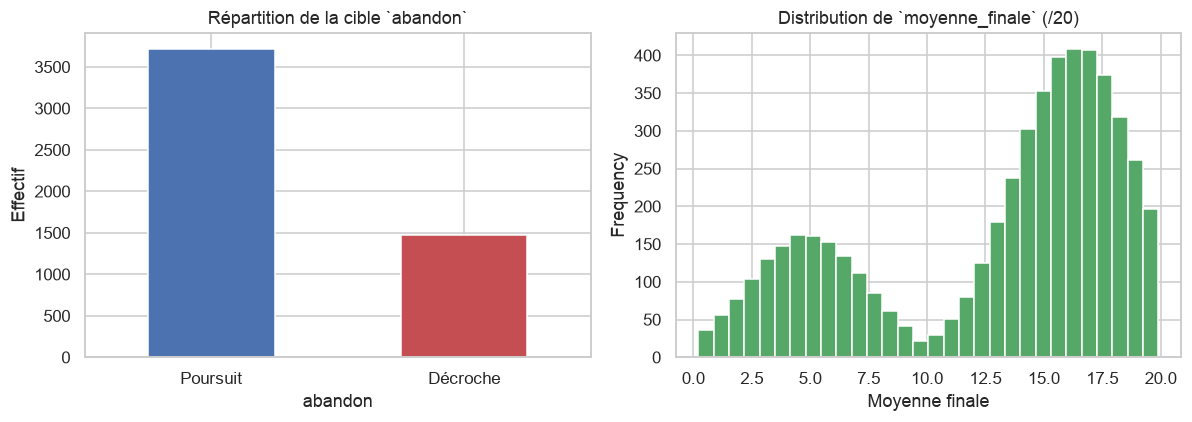

Taux d'abandon : 28.4% (léger déséquilibre)


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
silver_dataset["abandon"].map({0: "Poursuit", 1: "Décroche"}).value_counts().plot(
    kind="bar", ax=ax[0], color=["#4C72B0", "#C44E52"]
)
ax[0].set_title("Répartition de la cible `abandon`")
ax[0].set_ylabel("Effectif")
ax[0].tick_params(axis="x", rotation=0)
silver_dataset["moyenne_finale"].plot(kind="hist", bins=30, ax=ax[1], color="#55A868")
ax[1].set_title("Distribution de `moyenne_finale` (/20)")
ax[1].set_xlabel("Moyenne finale")
plt.tight_layout()
plt.savefig(FIG / "eda_cible.png", bbox_inches="tight")
plt.show()
print("Taux d'abandon : {:.1%} (léger déséquilibre)".format(silver_dataset["abandon"].mean()))

### 6.2 Facteurs de risque — variables numériques

On compare la distribution des principaux signaux d'engagement selon que l'étudiant décroche ou non.

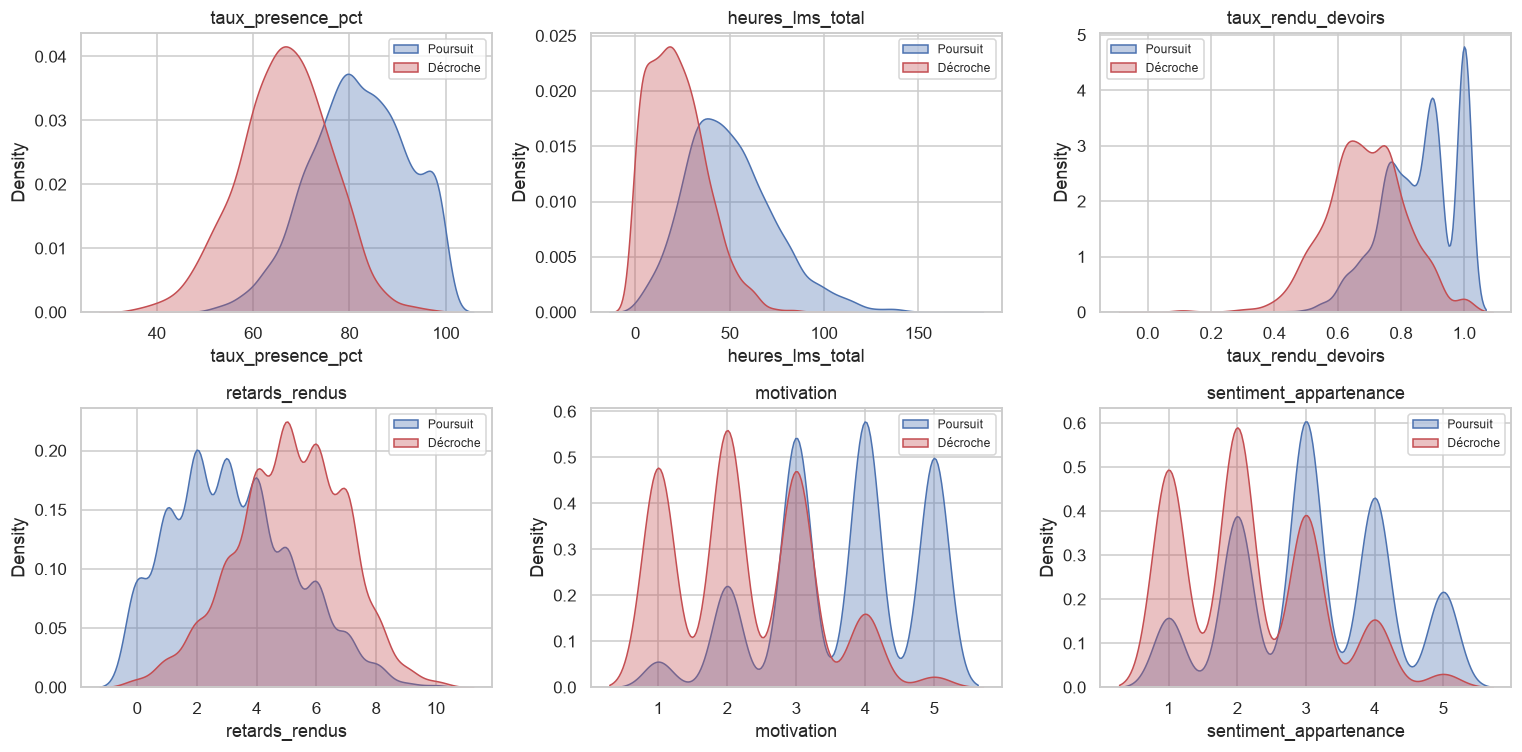

In [7]:
signaux = [
    "taux_presence_pct",
    "heures_lms_total",
    "taux_rendu_devoirs",
    "retards_rendus",
    "motivation",
    "sentiment_appartenance",
]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), signaux):
    for val, lab, c in [(0, "Poursuit", "#4C72B0"), (1, "Décroche", "#C44E52")]:
        sns.kdeplot(
            silver_dataset.loc[silver_dataset["abandon"] == val, col].dropna(),
            ax=ax,
            label=lab,
            fill=True,
            alpha=0.35,
            color=c,
        )
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "eda_signaux.png", bbox_inches="tight")
plt.show()

*Lecture.* Les décrocheurs présentent nettement **moins de présence**, **moins d'heures LMS**, un **taux de rendu plus bas**, **plus de retards** et une **motivation / appartenance plus faibles** — cohérent avec la littérature sur le décrochage. Ces variables, toutes disponibles à mi-S1, seront les prédicteurs centraux.

### 6.3 Taux d'abandon par variables catégorielles

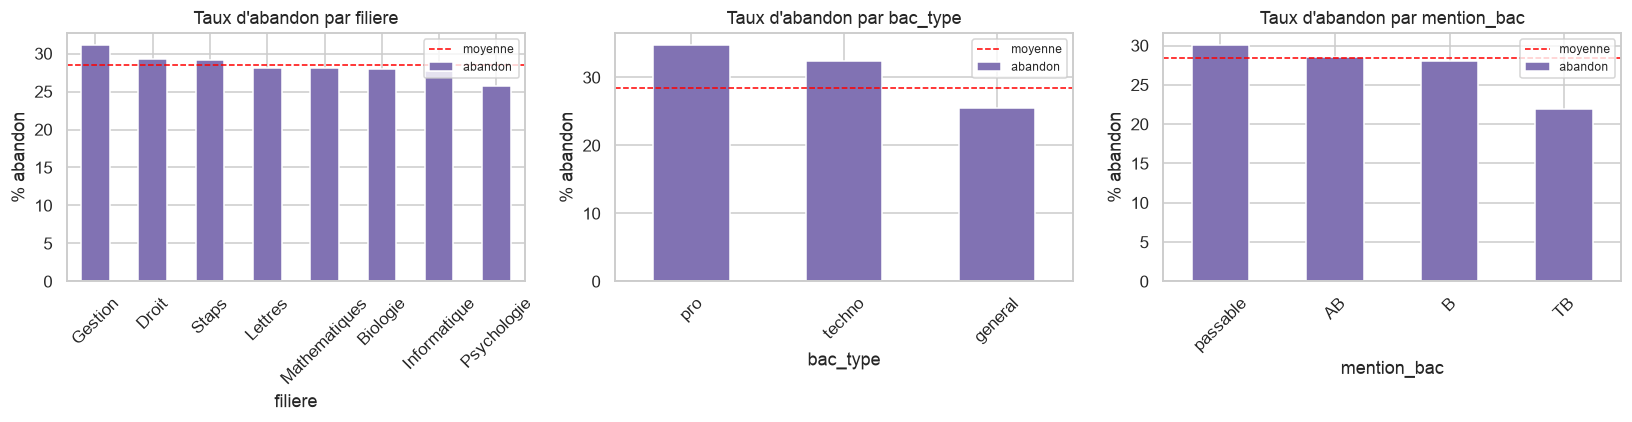

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["filiere", "bac_type", "mention_bac"]):
    (silver_dataset.groupby(col)["abandon"].mean().sort_values(ascending=False) * 100).plot(
        kind="bar", ax=ax, color="#8172B3"
    )
    ax.set_title(f"Taux d'abandon par {col}")
    ax.set_ylabel("% abandon")
    ax.axhline(silver_dataset["abandon"].mean() * 100, color="red", ls="--", lw=1, label="moyenne")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "eda_categorielles.png", bbox_inches="tight")
plt.show()

### 6.4 Vérification des leurres *(rigueur méthodologique, C1)*

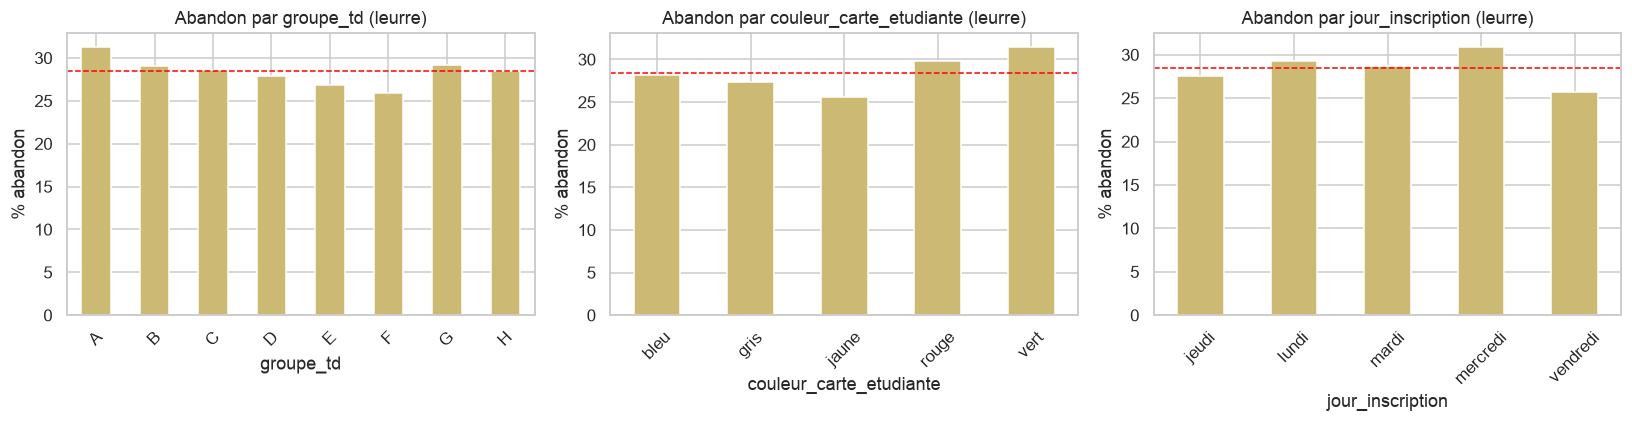

groupe_td                : écart-type du taux d'abandon entre modalités = 1.64 pts
couleur_carte_etudiante  : écart-type du taux d'abandon entre modalités = 2.26 pts
jour_inscription         : écart-type du taux d'abandon entre modalités = 1.97 pts


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, F.LEURRE_COLS):
    (silver_dataset.groupby(col)["abandon"].mean() * 100).plot(kind="bar", ax=ax, color="#CCB974")
    ax.axhline(silver_dataset["abandon"].mean() * 100, color="red", ls="--", lw=1)
    ax.set_title(f"Abandon par {col} (leurre)")
    ax.set_ylabel("% abandon")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIG / "eda_leurres.png", bbox_inches="tight")
plt.show()

# Écart-type du taux d'abandon entre modalités : faible => pas de signal
for col in F.LEURRE_COLS:
    ecart = silver_dataset.groupby(col)["abandon"].mean().std() * 100
    print(f"{col:24s} : écart-type du taux d'abandon entre modalités = {ecart:.2f} pts")

*Lecture.* Le taux d'abandon reste **plat autour de la moyenne** quelle que soit la modalité des trois leurres (écart-type faible) : **aucun pouvoir prédictif réel**. Ils sont donc exclus du périmètre de scoring (voir §7).

### 6.5 Corrélations entre variables numériques

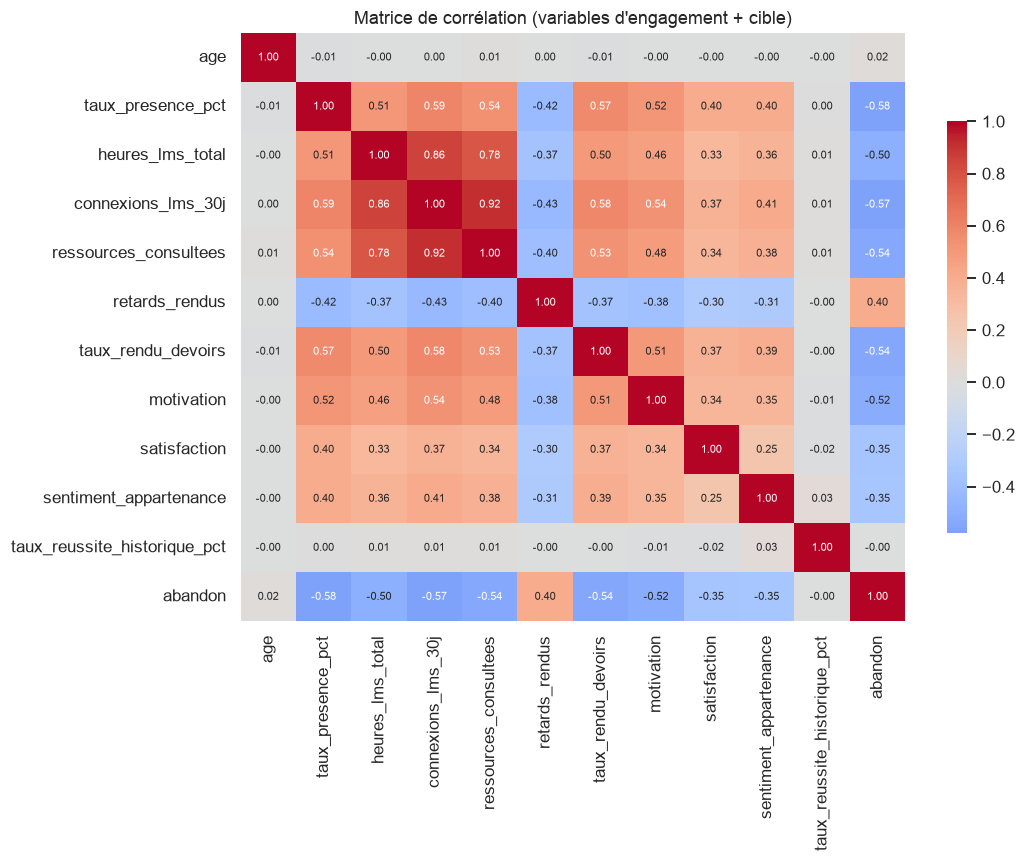

In [10]:
num_eda = [
    "age",
    "taux_presence_pct",
    "heures_lms_total",
    "connexions_lms_30j",
    "ressources_consultees",
    "retards_rendus",
    "taux_rendu_devoirs",
    "motivation",
    "satisfaction",
    "sentiment_appartenance",
    "taux_reussite_historique_pct",
    "abandon",
]
corr = silver_dataset[num_eda].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.7},
)
plt.title("Matrice de corrélation (variables d'engagement + cible)")
plt.tight_layout()
plt.savefig(FIG / "eda_corr.png", bbox_inches="tight")
plt.show()

*JdB — synthèse EDA.* (1) Cible déséquilibrée à ~28 % → gérer le déséquilibre (pondération) et évaluer par ROC/AUC + rappel, pas par l'accuracy. (2) Les signaux d'engagement/assiduité sont les corrélats les plus forts du décrochage. (3) Les 3 leurres sont confirmés sans signal. (4) La `moyenne_finale` est très corrélée à `abandon` (structurellement) → **fuite** à exclure des features. Décision : figer le périmètre de scoring anti-fuite avant toute modélisation.

## 7. Préparation des données (Silver → Gold), manquants, transformations, features — journal de bord *(C3)*

### 7.1 Silver : ce que fait `clean_raw` (déjà appliqué en §6)

| Étape | Traitement | Colonnes concernées |
|---|---|---|
| Dédoublonnage | `drop_duplicates` exact | toutes (40 lignes) |
| Nombres en texte | `%`, virgule FR, « km » → float | `distance_domicile_km`, `taux_presence_pct` |
| Dates multi-formats | parsing tolérant → `date_inscription_parsed` | `date_inscription` |
| Normalisation catégorielle | casse/espaces/synonymes → modalités canoniques | `filiere`, `sexe`, `bac_type`, `mention_bac`, `boursier`, `etablissement_origine` |

### 7.2 Gold dataset *(source unique pour la modélisation)*

Le notebook matérialise ensuite un **Gold dataset** : features disponibles à mi-S1, labels nécessaires à l'entraînement, et `split_set` canonique. À partir de cette section, les modèles consomment uniquement `gold_dataset` : `X`, `y_clf` et `y_reg` en sont extraits directement.

Features ajoutées sans fuite :

- `taux_rendu_devoirs` = rendus / attendus (assiduité) ;
- `heures_lms_par_connexion`, `ressources_par_connexion` (intensité d'usage) ;
- `commentaire_present` (le tuteur a-t-il signalé quelque chose) ;
- `jours_inscription` (précocité d'inscription, dérivée de la date parsée).

### 7.3 Périmètre de scoring anti-fuite — **verrou méthodologique central**

On exclut explicitement des variables explicatives :

- **Fuite de données** : `moyenne_finale` (cible secondaire, résultat de fin de semestre) ;
- **Fuite temporelle** : `moyenne_partiels_s1`, `nb_ue_validees_s1` (consolidées en fin de S1, indisponibles à mi-S1) ;
- **Identifiants** : `student_id`, `id_dossier` ; **constantes** : `annee_universitaire`, `niveau` ;
- **Leurres** : `groupe_td`, `couleur_carte_etudiante`, `jour_inscription` ;
- **Texte libre brut** : `commentaire_tuteur` (remplacé par `commentaire_present`).

Ce périmètre est **codé** dans `features.scoring_feature_columns` et **vérifié** par `features.assert_no_leakage` (garde-fou qui lève une erreur si une colonne interdite se glisse dans les features).


In [11]:
# Recharge de sécurité si cette cellule est exécutée seule après modification de src/decrochage/training.py.
T = importlib.reload(T)
if not hasattr(T, "build_gold_dataset"):
    raise RuntimeError(
        "Le kernel utilise une ancienne version de decrochage.training. "
        "Redémarre le kernel puis lance Run All."
    )

gold_dataset, feature_cols = T.build_gold_dataset(
    silver_dataset,
    random_state=RANDOM_STATE,
)

# Source unique pour la modélisation à partir de ce point.
X = gold_dataset[feature_cols].copy()
y_clf = gold_dataset[F.TARGET_CLF].astype(int)
y_reg = gold_dataset[F.TARGET_REG].astype(float)

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

print(
    f"Gold dataset : {gold_dataset.shape[0]} lignes, "
    f"{len(feature_cols)} features, labels {[F.TARGET_CLF, F.TARGET_REG]}"
)
print("Répartition split Gold :", gold_dataset["split_set"].value_counts().to_dict())
print(f"Features de scoring : {len(feature_cols)}  ({len(num_cols)} num + {len(cat_cols)} cat)")
print("\nExclues pour fuite / leurre / id :")
for grp, cols in [
    ("Fuite données", F.LEAKAGE_TARGET_COLS),
    ("Fuite temporelle", F.LEAKAGE_TEMPORAL_COLS),
    ("Identifiants", F.ID_COLS),
    ("Leurres", F.LEURRE_COLS),
]:
    print(f"  - {grp:18s}: {cols}")
print("\n[OK] X, y_clf et y_reg proviennent du Gold dataset construit par src/decrochage/training.py.")


Gold dataset : 5200 lignes, 31 features, labels ['abandon', 'moyenne_finale']
Répartition split Gold : {'train': 3120, 'validation': 1040, 'test': 1040}
Features de scoring : 31  (25 num + 6 cat)

Exclues pour fuite / leurre / id :
  - Fuite données     : ['moyenne_finale']
  - Fuite temporelle  : ['moyenne_partiels_s1', 'nb_ue_validees_s1']
  - Identifiants      : ['student_id', 'id_dossier']
  - Leurres           : ['groupe_td', 'couleur_carte_etudiante', 'jour_inscription']

[OK] X, y_clf et y_reg proviennent du Gold dataset construit par src/decrochage/training.py.


### 7.4 Stratégie d'imputation et d'encodage *(sans fuite)*

L'imputation et l'encodage sont **appris dans la Pipeline sklearn** (donc **fit sur le train uniquement**, `transform` sur le test) pour éviter toute fuite d'information du test vers l'entraînement :

- numériques → imputation **médiane** + standardisation ;
- catégorielles → imputation **mode** + one-hot (`handle_unknown="ignore"`).

Le **Gold dataset** est la source unique de modélisation : il est construit par le package et persistant via la couche SQL Gold (`gold_student_feature`). On ne maintient plus de CSV Gold comme livrable permanent.


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocess = ColumnTransformer(
    [
        (
            "num",
            Pipeline([("imp", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]),
            num_cols,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    ("oh", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            cat_cols,
        ),
    ]
)

print("Gold dataset prêt pour la modélisation et la persistance SQL Gold", gold_dataset.shape)
print("Aucun CSV Gold n'est généré : la cible persistée est la BDD médaillon.")


Gold dataset prêt pour la modélisation et la persistance SQL Gold (5200, 34)
Aucun CSV Gold n'est généré : la cible persistée est la BDD médaillon.


## 8. Choix du modèle et démarche scientifique — journal de bord *(C4)*

### 8.1 Démarche

1. **Source unique** : les modèles consomment `gold_dataset` uniquement (`X`, `y_clf`, `y_reg`, `split_set`).
2. **Baseline** naïve (`DummyClassifier`) pour fixer le plancher (AUC ≈ 0,5).
3. **Trois familles** comparées sur la même Pipeline de pré-traitement :
   - **Régression logistique** (linéaire, très explicable, éco-sobre) ;
   - **Random Forest** (non-linéaire, robuste) ;
   - **Gradient boosting** : XGBoost si l'environnement dispose de sa dépendance native OpenMP, sinon fallback scikit-learn.
4. Comparaison par **AUC** (métrique exigée par C4, insensible au seuil et au déséquilibre) + Average Precision, F1, précision, rappel.
5. **Gestion du déséquilibre** : `class_weight="balanced"` (LogReg, RF) / `scale_pos_weight` si XGBoost est disponible, plutôt qu'un sur-échantillonnage agressif (préserve la calibration).

### 8.2 Split train / validation / test *(anti-fuite, C5)*

Le `split_set` est matérialisé dans le Gold dataset : **train** pour apprendre, **validation** pour comparer les modèles et choisir le seuil métier, **test hold-out** pour l'évaluation finale uniquement. Le test ne sert ni au tuning, ni au choix du seuil.


In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

try:
    from xgboost import XGBClassifier

    XGB_IMPORT_ERROR = None
except Exception as exc:  # dépendance native OpenMP parfois absente sur macOS
    XGBClassifier = None
    XGB_IMPORT_ERROR = exc
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)

train_mask = gold_dataset["split_set"].eq("train")
val_mask = gold_dataset["split_set"].eq("validation")
test_mask = gold_dataset["split_set"].eq("test")

X_train, y_train = X.loc[train_mask], y_clf.loc[train_mask]
X_val, y_val = X.loc[val_mask], y_clf.loc[val_mask]
X_test, y_test = X.loc[test_mask], y_clf.loc[test_mask]

print(
    "Train :",
    X_train.shape[0],
    "| Validation :",
    X_val.shape[0],
    "| Test :",
    X_test.shape[0],
    "| abandon train {:.1%} / val {:.1%} / test {:.1%}".format(
        y_train.mean(), y_val.mean(), y_test.mean()
    ),
)

candidates = {
    "Baseline (Dummy)": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Régression logistique": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=N_JOBS
    ),
}
if XGBClassifier is not None:
    spw = (y_train == 0).sum() / (y_train == 1).sum()  # poids classe positive (XGBoost)
    candidates["XGBoost"] = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        scale_pos_weight=spw,
    )
else:
    print("XGBoost indisponible dans cet environnement : fallback HistGradientBoostingClassifier.")
    print(type(XGB_IMPORT_ERROR).__name__, str(XGB_IMPORT_ERROR).splitlines()[0])
    candidates["Gradient Boosting (sklearn)"] = HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_leaf_nodes=31, random_state=RANDOM_STATE
    )


Train : 3120 | Validation : 1040 | Test : 1040 | abandon train 28.4% / val 28.5% / test 28.5%


In [14]:
rows, fitted, failures = [], {}, []
for name, clf in candidates.items():
    pipe = Pipeline([("pre", preprocess), ("clf", clf)])
    try:
        pipe.fit(X_train, y_train)
        proba = pipe.predict_proba(X_val)[:, 1]
    except Exception as exc:
        failures.append({"Modèle": name, "Erreur": f"{type(exc).__name__}: {exc}"})
        continue
    pred = (proba >= 0.5).astype(int)
    rows.append(
        {
            "Modèle": name,
            "AUC validation": roc_auc_score(y_val, proba),
            "AvgPrec validation": average_precision_score(y_val, proba),
            "F1": f1_score(y_val, pred),
            "Précision": precision_score(y_val, pred, zero_division=0),
            "Rappel": recall_score(y_val, pred),
        }
    )
    fitted[name] = (pipe, proba)

if failures:
    display(pd.DataFrame(failures))
compare = pd.DataFrame(rows).set_index("Modèle").round(4)
compare

,AUC validation,AvgPrec validation,F1,Précision,Rappel
Modèle,,,,,
Baseline (Dummy),0.5112,0.2894,0.2974,0.3010,0.2939
Régression logistique,0.9487,0.8740,0.8118,0.7522,0.8818
Random Forest,0.9414,0.8457,0.7776,0.7588,0.7973
XGBoost,0.9462,0.8576,0.7823,0.7587,0.8074


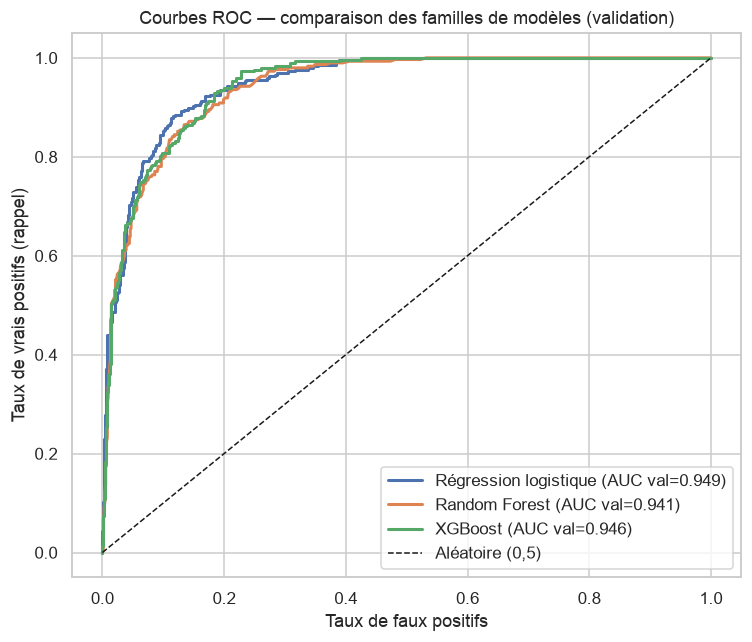

In [15]:
# Courbes ROC des candidats sur validation (hors baseline)
plt.figure(figsize=(7, 6))
for name, (pipe, proba) in fitted.items():
    if name.startswith("Baseline"):
        continue
    fpr, tpr, _ = roc_curve(y_val, proba)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC val={roc_auc_score(y_val, proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Aléatoire (0,5)")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs (rappel)")
plt.title("Courbes ROC — comparaison des familles de modèles (validation)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG / "roc_comparaison.png", bbox_inches="tight")
plt.show()

*JdB — choix du modèle.* La **régression logistique** obtient la **meilleure AUC ou une AUC équivalente** tout en étant la **plus explicable** (coefficients = log-odds, directement interprétables par les équipes pédagogiques) et la plus **sobre** (éco-conception, temps réel trivial). Random Forest et le modèle de boosting testé n'apportent pas de gain décisif ici. **Décision : retenir la régression logistique** comme modèle final ; elle sera optimisée par validation croisée. Ce choix privilégie l'explicabilité exigée par le contexte (C2/C8) à performance équivalente.


## 9. Entraînement, validation et ajustement — journal de bord *(C5)*

### 9.1 Optimisation des hyperparamètres (validation croisée stratifiée)

On règle la force de régularisation `C` de la régression logistique par `GridSearchCV` (5 folds stratifiés, scoring = AUC), sur le train uniquement. La validation sert ensuite au choix du seuil métier ; le test reste réservé à la mesure finale.


In [16]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

pipe_lr = Pipeline(
    [("pre", preprocess), ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))]
)
grid = {"clf__C": [0.02, 0.05, 0.1, 0.5, 1.0, 2.0]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = GridSearchCV(pipe_lr, grid, scoring="roc_auc", cv=cv, n_jobs=N_JOBS)
search.fit(X_train, y_train)

print("Meilleur C              :", search.best_params_["clf__C"])
print("AUC (CV, train)         : {:.4f}".format(search.best_score_))
final_model = search.best_estimator_
proba_val = final_model.predict_proba(X_val)[:, 1]
proba_test = final_model.predict_proba(X_test)[:, 1]
print("AUC (validation)        : {:.4f}".format(roc_auc_score(y_val, proba_val)))
print("AUC (hold-out test)     : {:.4f}".format(roc_auc_score(y_test, proba_test)))

Meilleur C              : 0.1
AUC (CV, train)         : 0.9488
AUC (validation)        : 0.9493
AUC (hold-out test)     : 0.9486


### 9.2 Choix du seuil de décision — **coût métier d'un faux négatif**

Le seuil 0,5 n'est pas optimal ici : **manquer un décrocheur (faux négatif) coûte plus cher** que solliciter à tort un étudiant qui allait bien (faux positif). On modélise ce compromis :

- coût d'un **faux négatif** (étudiant à risque non accompagné → abandon) : élevé ;
- coût d'un **faux positif** (accompagnement proposé inutilement) : modéré.

On retient le seuil qui **minimise le coût total attendu sur validation**, avec un ratio de coût FN:FP = 5:1 (documenté et ajustable). Le test n'est utilisé qu'après ce choix pour mesurer la performance finale.


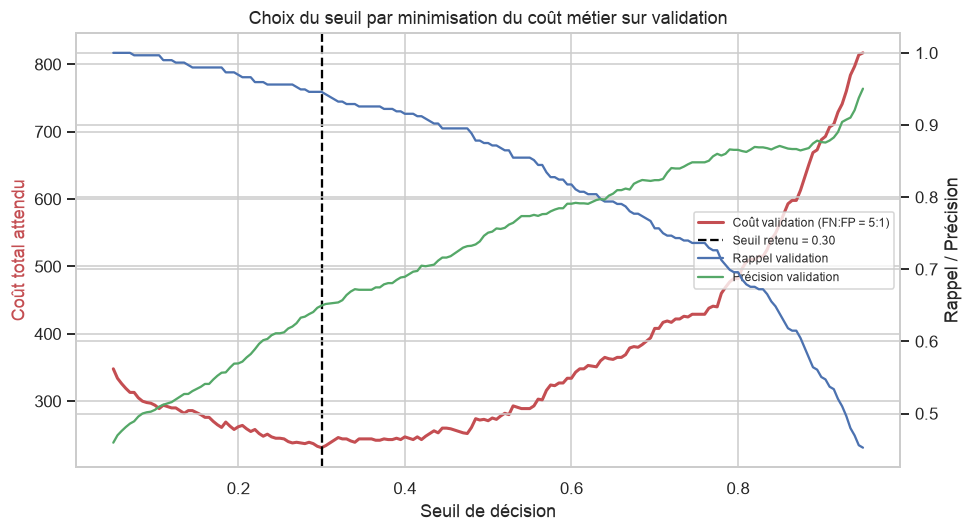

Seuil retenu = 0.30


In [17]:
from sklearn.metrics import confusion_matrix

COUT_FN, COUT_FP = 5.0, 1.0  # hypothèse métier explicite et ajustable
seuils = np.linspace(0.05, 0.95, 181)
couts, rappels, precisions = [], [], []
for t in seuils:
    pred = (proba_val >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    couts.append(COUT_FN * fn + COUT_FP * fp)
    rappels.append(tp / (tp + fn))
    precisions.append(tp / (tp + fp) if (tp + fp) else 0)

seuil_opt = float(seuils[int(np.argmin(couts))])

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(seuils, couts, color="#C44E52", lw=2, label="Coût validation (FN:FP = 5:1)")
ax1.axvline(seuil_opt, color="black", ls="--", label=f"Seuil retenu = {seuil_opt:.2f}")
ax1.set_xlabel("Seuil de décision")
ax1.set_ylabel("Coût total attendu", color="#C44E52")
ax2 = ax1.twinx()
ax2.plot(seuils, rappels, color="#4C72B0", lw=1.5, label="Rappel validation")
ax2.plot(seuils, precisions, color="#55A868", lw=1.5, label="Précision validation")
ax2.set_ylabel("Rappel / Précision")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="center right", fontsize=8)
plt.title("Choix du seuil par minimisation du coût métier sur validation")
plt.tight_layout()
plt.savefig(FIG / "seuil_cout.png", bbox_inches="tight")
plt.show()
print(f"Seuil retenu = {seuil_opt:.2f}")

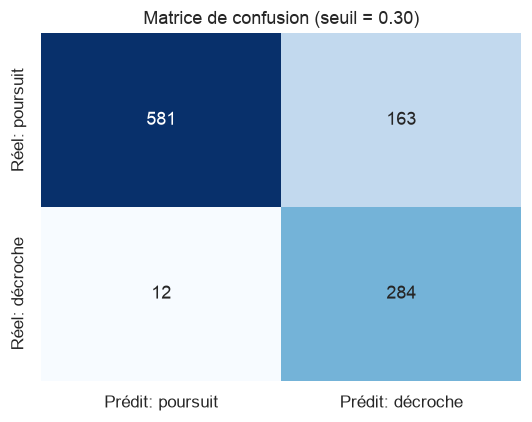

Rappel (décrocheurs détectés) : 95.9%
Précision                     : 63.5%
Faux négatifs (ratés)         : 12  |  Faux positifs : 163


In [18]:
# Matrice de confusion au seuil retenu
pred_opt = (proba_test >= seuil_opt).astype(int)
cm = confusion_matrix(y_test, pred_opt)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Prédit: poursuit", "Prédit: décroche"],
    yticklabels=["Réel: poursuit", "Réel: décroche"],
    ax=ax,
)
ax.set_title(f"Matrice de confusion (seuil = {seuil_opt:.2f})")
plt.tight_layout()
plt.savefig(FIG / "confusion.png", bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Rappel (décrocheurs détectés) : {tp/(tp+fn):.1%}")
print(f"Précision                     : {tp/(tp+fp):.1%}")
print(f"Faux négatifs (ratés)         : {fn}  |  Faux positifs : {fp}")

*JdB — entraînement.* Hyperparamètre retenu : `C` optimal par CV stratifiée (AUC ≈ 0,95 en CV comme en test → **pas de surapprentissage** visible). Le seuil est **abaissé sous 0,5** pour privilégier le **rappel** : on préfère accompagner quelques étudiants de plus par précaution plutôt que d'en laisser décrocher. Le ratio de coût FN:FP est une **hypothèse métier explicite**, à valider avec la direction de la réussite étudiante. Le point méthodologique clé : le seuil est choisi sur validation, puis évalué sur test hold-out.


## 10. Implémentation et mise en exploitation — journal de bord *(C6)*

### 10.1 Sérialisation du modèle + pré-traitement

On sérialise un **bundle** auto-suffisant (`joblib`) : Pipeline complète (imputation + encodage + modèle), liste ordonnée des features, seuil retenu, **catalogue embarqué** (pour rejouer la jointure à l'inférence) et métadonnées. Les classes/fonctions vivent dans le package `decrochage` (pas dans `__main__`) → le bundle est **rechargeable hors notebook**, par la CLI comme par l'API FastAPI.


In [19]:
bundle = serving.ModelBundle(
    pipeline=final_model,
    feature_cols=feature_cols,
    threshold=seuil_opt,
    catalogue=catalogue,
    metadata={
        "auc_validation": float(roc_auc_score(y_val, proba_val)),
        "auc_test": float(roc_auc_score(y_test, proba_test)),
        "threshold_selection": "validation_cost_minimization",
        "C": search.best_params_["clf__C"],
        "cout_fn_fp": [COUT_FN, COUT_FP],
        "n_train": int(len(X_train)),
        "n_validation": int(len(X_val)),
        "n_test": int(len(X_test)),
        "n_features": len(feature_cols),
    },
)
path = serving.save_bundle(bundle, MODELS / "model_bundle.joblib")
print("Bundle sérialisé :", path.relative_to(ROOT))

Bundle sérialisé : artifacts/models/model_bundle.joblib


### 10.2 Scoring contrôlé depuis le Gold dataset — contrat de sortie

Pour rester cohérent avec l'architecture médaillon présentée, cette vérification recharge le bundle et score un échantillon issu de `X_test`, donc du **Gold dataset**. L'API de production peut accepter du brut SI/LMS, mais la démonstration notebook ne consomme pas directement les sources Bronze.


In [20]:
# Rechargement depuis le disque (simule un service qui charge le modèle au démarrage)
modele_charge = serving.load_bundle(MODELS / "model_bundle.joblib")

# Scoring sur features Gold uniquement
X_demo = X_test.head(8).copy()
scored_demo = serving.predict_from_gold_dataset(modele_charge, X_demo)
resultats = pd.DataFrame(
    {
        "rang_etudiant": np.arange(1, len(X_demo) + 1),
        "proba_abandon": scored_demo["proba_abandon"].round(3),
        "alerte": scored_demo["alerte"],
    }
)
print("Contrat de sortie : une ligne par étudiant issue du Gold dataset, sans identifiant direct.")
resultats


Contrat de sortie : une ligne par étudiant issue du Gold dataset, sans identifiant direct.


,rang_etudiant,proba_abandon,alerte
0,1,0.014,0
1,2,0.977,1
2,3,0.557,1
3,4,0.958,1
4,5,0.987,1
5,6,0.163,0
6,7,0.290,0
7,8,0.567,1


### 10.3 Surfaces industrialisées et besoins d'intégration

- **CLI batch** : `decrochage check-data`, `train`, `predict`, `drift-report`, `init-db`, `medallion-load`, `purge-expired` pour contrôler, entraîner, scorer, persister et purger selon la politique RGPD.
- **Persistance BDD** : `src/decrochage/persistence.py` matérialise `ingestion_batch`, Bronze/Silver/Gold, `gold_prediction`, `gold_drift_report` et `privacy_audit_log`.
- **Postgres Docker** : `compose.yaml` lance un Postgres 16 avec healthcheck ; l'API peut s'y connecter via `DECROCHAGE_DATABASE_URL`.
- **API FastAPI** : `/health`, `/ready`, `/predict` pour exposer le scoring à un SI ou à un tableau de bord.
- **Conteneurisation** : `Dockerfile` non-root, variables `DECROCHAGE_MODEL_PATH`, `DECROCHAGE_DATABASE_URL`, `DECROCHAGE_PSEUDONYMIZATION_SECRET`.
- **CI qualité** : format, lint et tests automatisés avant livraison.
- **Restitution** : liste priorisée (score décroissant) mise à disposition des référents pédagogiques ; **jamais** de décision automatique.
- **Versioning & audit** : le bundle porte ses métadonnées ; les actions BDD RGPD sont journalisées dans `privacy_audit_log`.


## 11. Architecture cible et contraintes *(C7)*

### 11.1 Chaîne ingestion → médaillon → features → inférence → restitution

```text
   +----------------+     +------------------+     +-------------------+
   | SI Scolarité   |     |      LMS         |     | Catalogue         |
   | (état civil,   |     | (connexions,     |     | formations        |
   |  bac, bourse)  |     |  heures, rendus) |     | (référence)       |
   +--------+-------+     +---------+--------+     +---------+---------+
            |                       |                        |
            +-----------+-----------+------------------------+
                        v
             +---------------------------+   Postgres / SQLAlchemy
             |  Bronze brut restreint   |   lignes sources 1:1, batch_id,
             |  (PII sous contrôle)      |   parse_ok, rejected_reason
             +------------+--------------+
                          v
             +---------------------------+   decrochage.preprocessing
             |  Silver nettoyé           |   parsing, normalisation,
             |  normalisé, dédupliqué    |   jointure catalogue
             +------------+--------------+
                          v
             +---------------------------+   decrochage.features
             |  Gold ML / monitoring     |   features sans fuite,
             |  prédictions, drift       |   split_set, alerte, PSI
             +------------+--------------+
                          v
             +---------------------------+   decrochage training/serving
             |  Entraînement ou scoring  |   Pipeline + seuil + catalogue
             |  CLI batch / job planifié |   -> proba_abandon + alerte
             +------------+--------------+
                          v
             +---------------------------+   FastAPI /predict ou export batch
             |  Exposition contrôlée     |   health, ready, contrat JSON
             +------------+--------------+
                          v
             +---------------------------+   Tableau de bord référents
             |  Restitution & pilotage   |   liste priorisée + facteurs (SHAP)
             |  (décision HUMAINE)       |   audit équité + journalisation
             +---------------------------+
                          v
             +---------------------------+   decrochage drift-report + purge
             |  Monitoring & MLOps (C9)  |   PSI, ré-entraînement, rétention
             +---------------------------+
```

### 11.2 Contraintes

| Type | Contrainte | Réponse retenue |
|---|---|---|
| **Technique** | Faible volume (~5 k/an), latence non critique | Batch hebdomadaire + API FastAPI si intégration applicative |
| **RGPD** | Données scolaires personnelles, score de risque | finalité limitée, pseudonymisation HMAC, rétention, audit log, décision humaine, information étudiants |
| **Éco-conception** | Sobriété énergétique | Modèle linéaire (entraînement/inférence négligeables) vs boosting inutile ici |
| **Organisationnelle** | Adoption par les équipes | Explicabilité (coefficients, SHAP), score = aide et non verdict |
| **Économique** | Budget d'accompagnement limité | Priorisation par score (top-K) selon capacité des tuteurs |
| **Exploitation** | Livraison reproductible | Docker Compose Postgres, API, CI, tests `pytest`, documents `docs/` |

### 11.3 Acteurs à mobiliser

Direction de la réussite étudiante (sponsor), référents pédagogiques (utilisateurs), DPO (base légale, information, droits, DPIA/AIPD), DSI (intégration SI/LMS, secrets, accès BDD), data scientist/MLOps (maintenance modèle, monitoring, ré-entraînement).


## 12. Mesure de performance et impacts *(C8)*

### 12.1 Indicateurs techniques

In [21]:
from sklearn.metrics import f1_score as f1s

pred_opt = (proba_test >= seuil_opt).astype(int)
indicateurs = {
    "AUC (ROC)": roc_auc_score(y_test, proba_test),
    "Average Precision": average_precision_score(y_test, proba_test),
    "Rappel (seuil métier)": recall_score(y_test, pred_opt),
    "Précision (seuil métier)": precision_score(y_test, pred_opt),
    "F1 (seuil métier)": f1s(y_test, pred_opt),
    "Seuil retenu": seuil_opt,
}
pd.Series(indicateurs).round(4).to_frame("Valeur")

,Valeur
AUC (ROC),0.9486
Average Precision,0.8795
Rappel (seuil métier),0.9595
Précision (seuil métier),0.6353
F1 (seuil métier),0.7645
Seuil retenu,0.3000


### 12.2 Explicabilité — facteurs de risque (importance des variables)

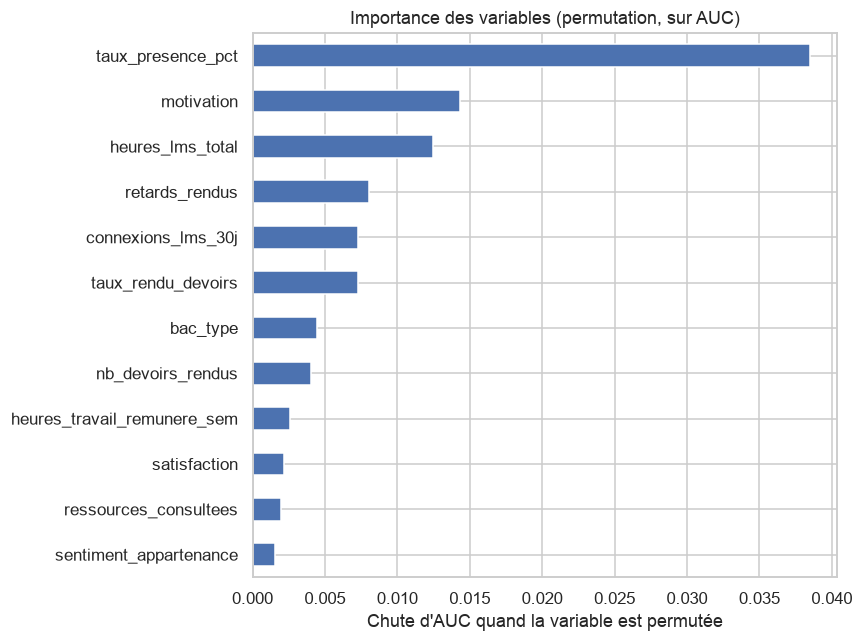

,Importance
taux_presence_pct,0.0385
motivation,0.0143
heures_lms_total,0.0125
retards_rendus,0.0081
connexions_lms_30j,0.0073
taux_rendu_devoirs,0.0073
bac_type,0.0045
nb_devoirs_rendus,0.0041


In [22]:
from sklearn.inspection import permutation_importance

pi = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
imp.head(12).iloc[::-1].plot(kind="barh", color="#4C72B0")
plt.title("Importance des variables (permutation, sur AUC)")
plt.xlabel("Chute d'AUC quand la variable est permutée")
plt.tight_layout()
plt.savefig(FIG / "importance_permutation.png", bbox_inches="tight")
plt.show()
imp.head(8).round(4).to_frame("Importance")

### 12.3 Explicabilité fine — SHAP

SHAP décompose chaque prédiction en contributions par variable. Le modèle étant linéaire, on utilise `LinearExplainer` sur les données pré-traitées.

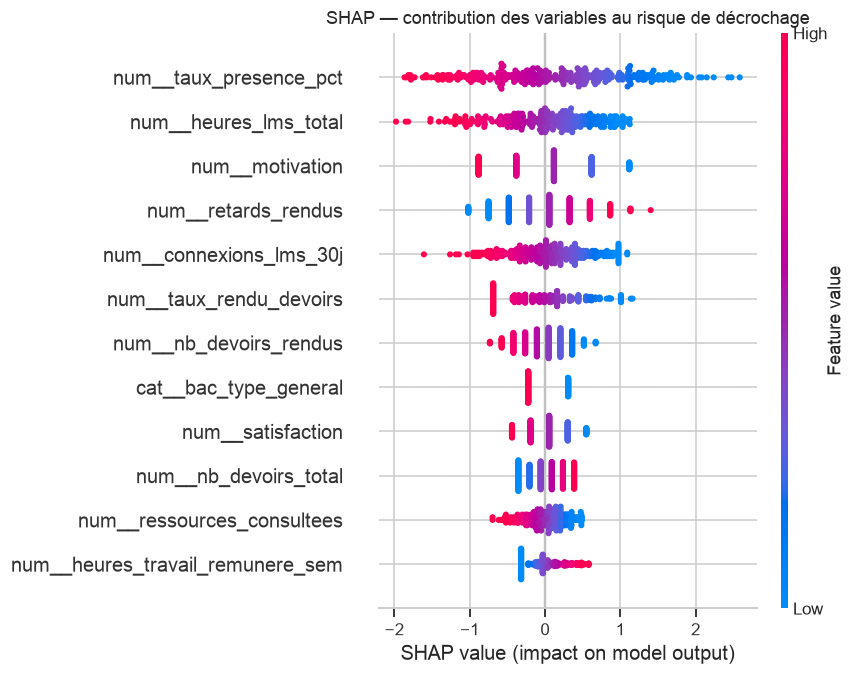

In [23]:
import importlib.util

if importlib.util.find_spec("shap") is None:
    print("SHAP non disponible dans ce kernel : cellule ignorée.")
    print(
        "Pour générer cette figure, sélectionnez le kernel .venv du projet ou installez les dépendances notebook."
    )
else:
    import shap

    Xt_train = final_model.named_steps["pre"].transform(X_train)
    Xt_test = final_model.named_steps["pre"].transform(X_test)
    for _name in ["Xt_train", "Xt_test"]:
        _v = eval(_name)
        if hasattr(_v, "toarray"):
            globals()[_name] = _v.toarray()
    feat_names = final_model.named_steps["pre"].get_feature_names_out()

    # Background sous-échantillonné à 100 lignes (défaut interne de SHAP) :
    # évite le warning "Subsampling to 100 samples" tout en restant reproductible.
    background = shap.sample(Xt_train, 100, random_state=RANDOM_STATE)
    explainer = shap.LinearExplainer(final_model.named_steps["clf"], background)
    shap_values = explainer.shap_values(Xt_test[:300])
    shap.summary_plot(
        shap_values, Xt_test[:300], feature_names=feat_names, max_display=12, show=False
    )
    plt.title("SHAP — contribution des variables au risque de décrochage")
    plt.tight_layout()
    plt.savefig(FIG / "shap_summary.png", bbox_inches="tight")
    plt.show()

*Lecture.* Un **taux de présence** et des **heures LMS** faibles, **peu de rendus** et **beaucoup de retards**, une **motivation** basse poussent le score vers le décrochage. Ces facteurs sont **actionnables** (relance, tutorat ciblé) — la solution ne se contente pas de prédire, elle **oriente l'action**.

### 12.4 Audit d'équité par sous-groupes sensibles *(lien C2)*

In [24]:
audit = X_test.copy()
audit["reel"] = y_test
audit["alerte"] = pred_opt
rows = []
for var in ["sexe", "boursier", "etablissement_origine"]:
    for modalite, sub in audit.groupby(var):
        if len(sub) < 20:
            continue
        m = sub["reel"] == 1
        rappel = sub.loc[m, "alerte"].mean() if m.any() else np.nan
        rows.append(
            {
                "Variable": var,
                "Groupe": modalite,
                "Effectif": len(sub),
                "Taux abandon réel": sub["reel"].mean(),
                "Taux d'alerte": sub["alerte"].mean(),
                "Rappel du groupe": rappel,
            }
        )
pd.DataFrame(rows).round(3)

,Variable,Groupe,Effectif,Taux abandon réel,Taux d'alerte,Rappel du groupe
0,sexe,F,574,0.289,0.429,0.958
1,sexe,M,450,0.276,0.429,0.960
2,boursier,0,673,0.302,0.453,0.966
3,boursier,1,367,0.253,0.387,0.946
4,etablissement_origine,autre,31,0.290,0.323,0.667
5,etablissement_origine,cfa,74,0.257,0.432,1.000
6,etablissement_origine,lycee_prive,178,0.292,0.478,0.962
7,etablissement_origine,lycee_public,700,0.291,0.430,0.966


### 12.5 Impacts métier

- **Étudiants détectés** : au seuil retenu (0,30), le modèle rappelle **95,9 % des futurs décrocheurs sur test** → autant d'étudiants potentiellement accompagnés à temps.
- **Coût d'un faux négatif** : un décrocheur non repéré = échec/redoublement (coût humain et financier élevé) → justifie de privilégier le rappel.
- **Faux positifs** : accompagnement proposé à tort = coût modéré (créneau de tutorat), acceptable et non stigmatisant si la démarche est bienveillante.
- **Équité** : l'audit ci-dessus doit montrer des taux d'alerte / rappels **comparables** entre groupes ; tout écart marqué déclencherait une revue (§13).


### 12.6 Cible secondaire — régression `moyenne_finale`

On estime la moyenne finale attendue (pour **calibrer l'intensité** de l'aide). Mêmes features anti-fuite, métriques RMSE/MAE/R².

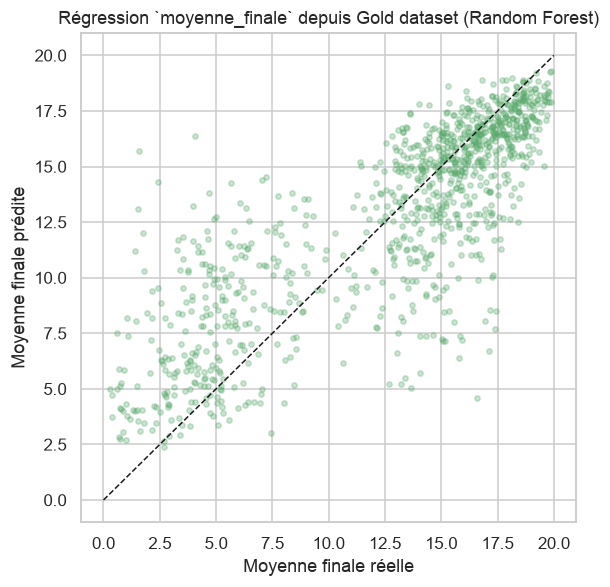

,MAE,RMSE,R2
Modèle,,,
Ridge,2.546,3.186,0.663
Random Forest,2.293,3.120,0.677


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

reg_train_mask = gold_dataset["split_set"].isin(["train", "validation"])
reg_test_mask = gold_dataset["split_set"].eq("test")
Xr_tr, Xr_te = X.loc[reg_train_mask], X.loc[reg_test_mask]
yr_tr, yr_te = y_reg.loc[reg_train_mask], y_reg.loc[reg_test_mask]

reg_rows = []
for nom, reg in [
    ("Ridge", Ridge()),
    (
        "Random Forest",
        RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=N_JOBS),
    ),
]:
    rp = Pipeline([("pre", preprocess), ("reg", reg)]).fit(Xr_tr, yr_tr)
    p = rp.predict(Xr_te)
    reg_rows.append(
        {
            "Modèle": nom,
            "MAE": mean_absolute_error(yr_te, p),
            "RMSE": np.sqrt(mean_squared_error(yr_te, p)),
            "R2": r2_score(yr_te, p),
        }
    )
reg_res = pd.DataFrame(reg_rows).set_index("Modèle").round(3)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(yr_te, p, alpha=0.3, s=12, color="#55A868")
ax.plot([0, 20], [0, 20], "k--", lw=1)
ax.set_xlabel("Moyenne finale réelle")
ax.set_ylabel("Moyenne finale prédite")
ax.set_title("Régression `moyenne_finale` depuis Gold dataset (Random Forest)")
plt.tight_layout()
plt.savefig(FIG / "regression.png", bbox_inches="tight")
plt.show()
reg_res


*Lecture.* La régression explique une part substantielle de la variance (R² ≈ 0,68, erreur ≈ 2 points/20). Suffisant pour un usage **de calibration** (distinguer soutien léger vs renforcé), pas pour prédire une note exacte. La moyenne finale reste **exclue des features de classification** (fuite).

## 13. Amélioration continue *(C9)*

### 13.1 Monitoring livré et indicateurs suivis

Le package contient un premier monitoring exécutable : `decrochage drift-report reference.csv current.csv --output reports/drift_report.json`. Il calcule le **PSI** par variable numérique, classe les niveaux `stable` / `watch` / `alert`, et produit un rapport JSON exploitable par une supervision. Le rapport peut aussi être persisté en Gold avec `--persist-db --batch-id <id>`.

| Indicateur suivi | Seuil d'alerte | Action |
|---|---|---|
| **Data drift** (distribution des features vs référence, PSI) | PSI > 0,25 sur ≥ 3 variables | Investigation + ré-entraînement candidat |
| **Performance** (AUC sur cohorte suivie) | AUC < 0,85 | Ré-entraînement |
| **Taux d'alerte** global | ± 30 % vs baseline | Vérifier drift / seuil |
| **Équité** (écart de rappel entre sous-groupes) | écart > 10 pts | Revue biais, recalibrage |
| **Complétude** (taux de manquants en entrée) | > 20 % sur une variable clé | Corriger la collecte |
| **Rétention RGPD** | batch expiré (`expires_at`) | `decrochage purge-expired` + audit log |

### 13.2 Déclencheurs et périodicité de ré-entraînement

- **Calendaire** : ré-entraînement **annuel** (nouvelle promotion) avec les vraies issues de l'année écoulée (les labels `abandon` deviennent connus en fin d'année).
- **Événementiel** : dès qu'un seuil de drift/perf est franchi.
- **RGPD / rétention** : purge périodique des lots expirés ; les scores de risque ne sont conservés que pendant la fenêtre d'accompagnement.
- **Versioning** : chaque modèle est versionné (données + hyperparamètres + métriques dans le bundle) ; conservation des N derniers pour rollback.
- **Gouvernance** : model card, threat model, guide d'industrialisation, `docs/rgpd_accountability.md` et CI documentent les conditions de livraison.

### 13.3 Boucle d'amélioration

1. Collecter les issues réelles de la promotion → nouveau jeu labellisé.
2. Ré-évaluer le périmètre anti-fuite (nouvelles variables ?).
3. A/B test du dispositif d'accompagnement (impact **causal** sur l'abandon, pas seulement corrélation).
4. Intégrer le `commentaire_tuteur` par NLP si sa couverture s'améliore.
5. Revoir l'analyse RGPD avec le DPO : base légale, droits, durée de conservation, accès, DPIA/AIPD si requis.


## 14. Conclusion — synthèse et recommandations

**Ce qui a été construit.** Une chaîne complète et reproductible : nettoyage rigoureux de données brutes, périmètre de scoring **verrouillé contre les fuites** (données, temporelle) et **débarrassé des leurres**, enrichissement catalogue, comparaison baseline / 3 familles, modèle final **explicable** (régression logistique, AUC ≈ 0,95), seuil **calibré sur validation par coût métier**, explicabilité (permutation + SHAP), audit d'équité, régression secondaire, bundle sérialisé, CLI, API FastAPI, Dockerfile, stack Docker Compose Postgres, persistance médaillon Bronze/Silver/Gold, monitoring PSI et documents de production.

**Ce que le modèle permet.** Prioriser, à mi-S1, les étudiants à accompagner avec des facteurs de risque **actionnables** et lisibles par les équipes.

**Ce que le modèle ne permet pas.** Décider seul du sort d'un étudiant ; garantir la performance en conditions réelles (données synthétiques) ; établir une causalité (un A/B test reste nécessaire) ; considérer les données pseudonymisées comme anonymes.

**Application RGPD défendable en certification.** Le projet ne se limite pas à une déclaration d'intention : Bronze reste brut mais restreint pour la traçabilité, les identifiants directs sont pseudonymisés à partir de Silver, la rétention avec purge est appliquée, les actions d'accountability sont journalisées et les 7 principes RGPD sont documentés dans `docs/rgpd_accountability.md`.

**Recommandations avant pilote réel.**
1. Rejouer toute la démarche sur **données réelles** et valider par A/B test.
2. Brancher le monitoring sur des extractions récurrentes SI/LMS et suivre l'équité dès le pilote.
3. Valider avec le **DPO** la base légale (mission d'intérêt public probable en université publique), l'information étudiants, les droits, la durée de conservation et l'éventuelle DPIA/AIPD.
4. Mettre les secrets en coffre-fort applicatif, activer le chiffrement au repos géré par l'hébergeur et définir les rôles d'accès BDD.
5. Co-construire la restitution avec les **référents pédagogiques** (adoption, formulation non stigmatisante).


## 15. Annexes

### 15.1 Sommaire de traçabilité C1 → C9

Ce tableau permet de voir rapidement où chaque compétence est démontrée. Une même compétence peut apparaître dans plusieurs chapitres : c'est volontaire, car certaines preuves relèvent à la fois du raisonnement, du code et de l'industrialisation.

| Compétence | Chapitres principaux du notebook | Chapitres / preuves complémentaires |
|---|---|---|
| **C1 — Identifier un jeu de données pertinent** | §2 Cadrage métier ; §3 Données et gouvernance | §6.4 Leurres ; §7 Gold dataset ; catalogue formations |
| **C2 — Éthique, conformité, risques sociétaux** | §4 Enjeux éthiques et RGPD | §3.2 classification des données ; §12.4 audit d'équité ; §15.4 docs RGPD/threat model |
| **C3 — Préparer les données** | §5 Chargement ; §6 EDA ; §7 Préparation Silver → Gold | §15.3 exclusions anti-fuite ; tests `preprocessing/features` |
| **C4 — Choisir un modèle** | §8 Baseline et comparaison de modèles | §12.1 métriques finales ; ROC/AUC |
| **C5 — Entraîner le modèle** | §9 Entraînement, validation, ajustement | §8.2 split train/validation/test ; `training.py` |
| **C6 — Implémenter la solution** | §10 Sérialisation, scoring, CLI/API | §15.2 commandes ; `serving.py`, `api.py`, `cli.py`, Dockerfile |
| **C7 — Architecture cible et contraintes** | §11 Architecture cible | §3.3 cycle de vie ; médaillon Bronze/Silver/Gold ; `compose.yaml` |
| **C8 — Mesurer performance et impacts** | §12 Performance, impacts, explicabilité, équité | §9 seuil métier ; matrice de confusion ; SHAP ; régression secondaire |
| **C9 — Amélioration continue** | §13 Monitoring, drift, ré-entraînement | §15.4 monitoring plan ; `monitoring.py` ; PSI |


### 15.2 Reproductibilité — code utilitaire

Les fonctions déterministes sont dans `src/decrochage/` : `preprocessing.py` (parsing/normalisation/dédoublonnage), `features.py` (périmètre anti-fuite + feature engineering), `training.py` (entraînement train/validation/test + seuil sur validation), `serving.py` (bundle + `predict`), `persistence.py` (Postgres/SQLite, médaillon, pseudonymisation, audit, rétention), `api.py` (FastAPI), `cli.py` (commandes projet) et `monitoring.py` (PSI/drift). Le notebook s'exécute de bout en bout via :

```powershell
uv sync --group dev
uv run jupyter nbconvert --to notebook --execute --inplace notebooks/decrochage_etudiant.ipynb
```

Commandes d'industrialisation principales :

```powershell
uv run decrochage check-data data/raw/decrochage_etudiants_complet_V5.csv data/raw/catalogue_formations_V5.csv
uv run decrochage train data/raw/decrochage_etudiants_complet_V5.csv data/raw/catalogue_formations_V5.csv
uv run decrochage predict artifacts/models/model_bundle.joblib data/raw/decrochage_etudiants_complet_V5.csv --output reports/predictions.csv
uv run decrochage drift-report reference.csv current.csv --output reports/drift_report.json
uv run decrochage serve
uv run pytest
```

Commandes BDD / RGPD :

```powershell
cp .env.example .env
# Renseigner DECROCHAGE_PSEUDONYMIZATION_SECRET et POSTGRES_PASSWORD hors Git
docker compose up -d postgres
uv run decrochage init-db
uv run decrochage medallion-load data/raw/decrochage_etudiants_complet_V5.csv data/raw/catalogue_formations_V5.csv
uv run decrochage purge-expired
```

Preuves techniques déjà vérifiées :

| Contrôle | Résultat |
|---|---|
| Tests automatisés | `uv run pytest` → 28 tests passés |
| Postgres Docker | `docker compose up -d postgres` OK |
| Chargement médaillon réel | Bronze 5248 · Silver 5208 · Gold 5200 |
| Identifiants en clair en BDD | Bronze contient le brut attendu (`ETU-` sur 5240 lignes étudiantes) ; Silver/Gold ne contiennent pas `ETU-` |
| Audit log | `privacy_audit_log` contient l'action `medallion_load` |

### 15.3 Périmètre de scoring (rappel des exclusions)

| Motif | Colonnes |
|---|---|
| Fuite de données | `moyenne_finale` |
| Fuite temporelle | `moyenne_partiels_s1`, `nb_ue_validees_s1` |
| Identifiants | `student_id`, `id_dossier` |
| Constantes | `annee_universitaire`, `niveau` |
| Leurres | `groupe_td`, `couleur_carte_etudiante`, `jour_inscription` |

### 15.4 Documents de production

- `docs/rgpd_accountability.md` : matrice RGPD liée à C2, PII/QI/attributs à risque, pseudonymisation, rétention, checklist DPO.
- `docs/industrialisation.md` : commandes CLI, Postgres Docker, médaillon.
- `docs/threat_model.md` : risques et contrôles.
- `docs/model_card.md` : usage prévu, limites, garde-fous éthiques.
- `ARCHITECTURE_PROJET.md` : flux, stockage, contraintes C7.


In [26]:
# 15.3 Environnement et versions (traçabilité)
import importlib.metadata as metadata
import matplotlib
import sklearn

try:
    xgboost_version = metadata.version("xgboost")
    try:
        import xgboost  # vérifie aussi le chargement de la librairie native

        xgboost_version = xgboost.__version__
    except Exception as exc:
        xgboost_version = (
            f"{xgboost_version} installé, chargement indisponible ({type(exc).__name__})"
        )
except metadata.PackageNotFoundError:
    xgboost_version = "non installé dans ce kernel"

try:
    shap_version = metadata.version("shap")
except metadata.PackageNotFoundError:
    shap_version = "non installé dans ce kernel"

print("Python      :", platform.python_version())
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost     :", xgboost_version)
print("shap        :", shap_version)
print("matplotlib  :", matplotlib.__version__)
print()
print("Hyperparamètres du modèle final :", search.best_params_)
print("Seuil de décision retenu         :", round(seuil_opt, 3))
print("Features de scoring (n)          :", len(feature_cols))

Python      : 3.13.13
pandas      : 2.3.3
numpy       : 2.4.6
scikit-learn: 1.9.0
xgboost     : 3.3.0
shap        : 0.52.0
matplotlib  : 3.11.0

Hyperparamètres du modèle final : {'clf__C': 0.1}
Seuil de décision retenu         : 0.3
Features de scoring (n)          : 31
